# Breast Cancer — BreakHis (200X) · 8-Subtype Multiclass · ResNet18



## 1 · Setup

In [3]:
import os, json, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, recall_score

SEED = 47
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Device:", DEVICE)

Torch: 2.5.1+cu121 | Device: cuda


## 2 · Locate data — the multiclass folder

In [5]:
# Same auto-locate, but point at the MULTICLASS task this time.
search_root = Path("..")
multi = next(search_root.rglob("classificacao_multiclasse"))
DATA_ROOT = multi             # one magnification, 8 subtype subfolders

classes = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())
NUM_CLASSES = len(classes)
print("Data root:", DATA_ROOT)
print(f"{NUM_CLASSES} classes:")
for c in classes:
    n = len(list((DATA_ROOT / c).glob("*.png")))
    print(f"  {c:<20}: {n}")
# Expect heavy imbalance: ductal_carcinoma dominates, adenosis/phyllodes are tiny.

Data root: ..\data\classificacao_multiclasse
8 classes:
  adenosis            : 111
  ductal_carcinoma    : 896
  fibroadenoma        : 264
  lobular_carcinoma   : 163
  mucinous_carcinoma  : 196
  papillary_carcinoma : 135
  phyllodes_tumor     : 108
  tubular_adenoma     : 140


## 3 · Transforms (ImageNet normalization is mandatory for the pretrained backbone)

In [6]:
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

## 4 · Stratified split (image-level)

Stratify on all 8 classes so every subtype appears in train/val/test. **Caveat:** image-level
means same-patient tiles can cross splits, so metrics may be optimistic. We accept this because
some subtypes have too few patients for a clean patient-level split; the limitation is documented.

In [8]:
train_base = ImageFolder(DATA_ROOT, transform=train_tfms)
eval_base  = ImageFolder(DATA_ROOT, transform=eval_tfms)

targets = np.array(train_base.targets)
idx = np.arange(len(targets))

train_idx, temp_idx = train_test_split(
    idx, test_size=0.20, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=targets[temp_idx], random_state=SEED)

train_ds = Subset(train_base, train_idx)
val_ds   = Subset(eval_base,  val_idx)
test_ds  = Subset(eval_base,  test_idx)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

train=1610  val=201  test=202


## 5 · A look at the data — distribution + one sample per subtype

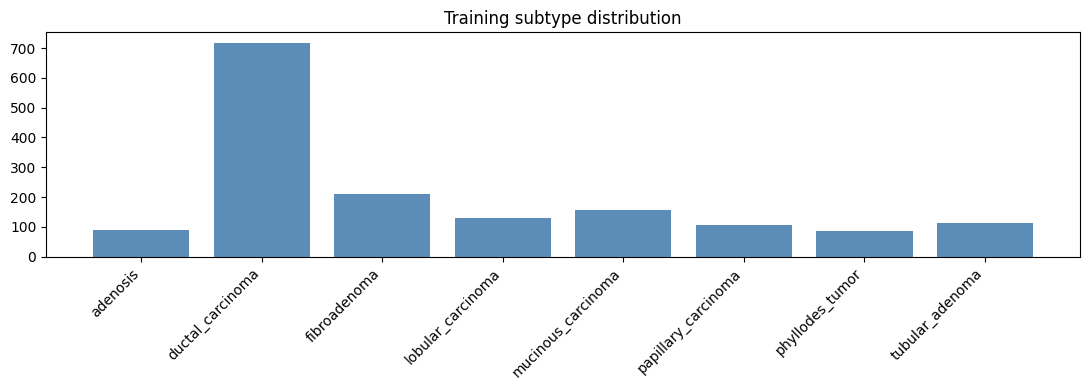

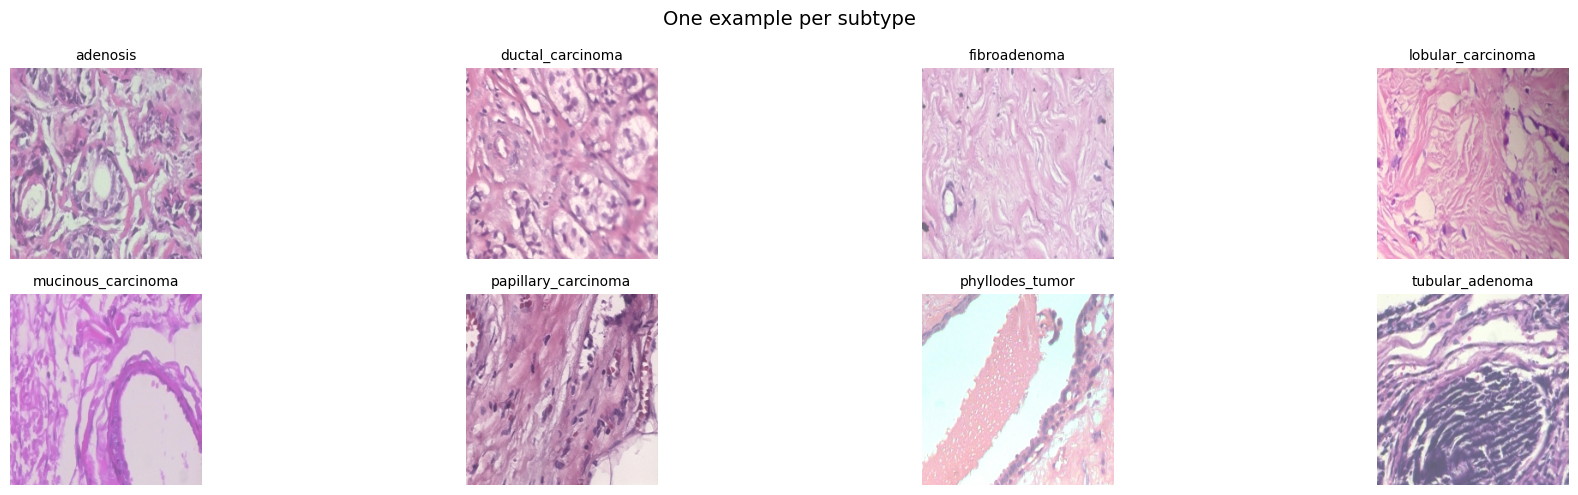

In [9]:
counts = [int((targets[train_idx] == k).sum()) for k in range(NUM_CLASSES)]
plt.figure(figsize=(11, 4))
plt.bar(range(NUM_CLASSES), counts, color="#5B8DB8")
plt.xticks(range(NUM_CLASSES), classes, rotation=45, ha="right")
plt.title("Training subtype distribution"); plt.tight_layout(); plt.show()

def denorm(t):
    t = t.numpy().transpose(1, 2, 0)
    return np.clip(t * STD + MEAN, 0, 1)

plt.figure(figsize=(20, 5))
for k in range(NUM_CLASSES):
    i = next(j for j in train_idx if targets[j] == k)
    img, _ = eval_base[i]
    plt.subplot(2, 4, k + 1); plt.imshow(denorm(img)); plt.axis("off")
    plt.title(classes[k], fontsize=10)
plt.suptitle("One example per subtype", fontsize=14)
plt.tight_layout(); plt.show()

## 6 · Class-weighted loss

Weight class $c$ by $w_c = N / (K \cdot n_c)$ — $N$ = total train images, $K$ = number of
classes, $n_c$ = count of class $c$. Rarer subtypes incur a larger penalty when missed, so the
model can't simply ignore them.

In [10]:
class_count = np.bincount(targets[train_idx], minlength=NUM_CLASSES)
N, K = len(train_idx), NUM_CLASSES
weights = torch.tensor(N / (K * class_count), dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
print("class weights:", weights.cpu().numpy().round(2))

BATCH, NUM_WORKERS = 32, 2   # set NUM_WORKERS=0 on Windows if it errors
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

class weights: [2.26 0.28 0.95 1.55 1.28 1.86 2.34 1.8 ]


## 7 · Model — ResNet18, head → 8 classes

In [11]:
def build_model():
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m.to(DEVICE)

def set_backbone_trainable(model, trainable):
    for name, p in model.named_parameters():
        if not name.startswith("fc."):
            p.requires_grad = trainable

model = build_model()
# Kaggle: Internet must be ON to download pretrained weights.
print(model.fc)

Linear(in_features=512, out_features=8, bias=True)


## 8 · Train / eval loop — tracking macro recall

In [12]:
def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    yt, yp = [], []
    torch.set_grad_enabled(train)
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        if train:
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        loss_sum += loss.item() * x.size(0)
        pred = logits.argmax(1)
        correct += (pred == y).sum().item(); total += x.size(0)
        yt += y.tolist(); yp += pred.tolist()
    torch.set_grad_enabled(True)
    macro_rec = recall_score(yt, yp, average="macro", zero_division=0)
    return loss_sum / total, correct / total, macro_rec

history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_recall": []}
best_macro, best_state = -1.0, None

def log(tag, tr, va):
    history["train_loss"].append(tr[0]); history["val_loss"].append(va[0])
    history["val_acc"].append(va[1]); history["val_macro_recall"].append(va[2])
    print(f"[{tag}] train_loss={tr[0]:.3f}  val_acc={va[1]:.3f}  "
          f"val_macro_recall={va[2]:.3f}")

### Phase 1 — head only (frozen backbone, lr 1e-3)

In [13]:
set_backbone_trainable(model, False)
opt = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
EPOCHS_HEAD = 5
for ep in range(1, EPOCHS_HEAD + 1):
    tr = run_epoch(model, train_loader, opt)
    va = run_epoch(model, val_loader)
    log(f"head {ep}/{EPOCHS_HEAD}", tr, va)
    if va[2] > best_macro:
        best_macro = va[2]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

[head 1/5] train_loss=1.959  val_acc=0.423  val_macro_recall=0.387
[head 2/5] train_loss=1.614  val_acc=0.443  val_macro_recall=0.516
[head 3/5] train_loss=1.426  val_acc=0.488  val_macro_recall=0.505
[head 4/5] train_loss=1.302  val_acc=0.567  val_macro_recall=0.562
[head 5/5] train_loss=1.229  val_acc=0.557  val_macro_recall=0.563


### Phase 2 — fine-tune all (unfrozen, lr 1e-4)

In [14]:
set_backbone_trainable(model, True)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
EPOCHS_FT = 8           # multiclass usually needs a few more epochs than binary
for ep in range(1, EPOCHS_FT + 1):
    tr = run_epoch(model, train_loader, opt)
    va = run_epoch(model, val_loader)
    log(f"ft {ep}/{EPOCHS_FT}", tr, va)
    if va[2] > best_macro:
        best_macro = va[2]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
print(f"\nBest val macro-recall: {best_macro:.3f}")

[ft 1/8] train_loss=0.898  val_acc=0.731  val_macro_recall=0.735
[ft 2/8] train_loss=0.463  val_acc=0.761  val_macro_recall=0.830
[ft 3/8] train_loss=0.366  val_acc=0.821  val_macro_recall=0.880
[ft 4/8] train_loss=0.277  val_acc=0.841  val_macro_recall=0.847
[ft 5/8] train_loss=0.256  val_acc=0.876  val_macro_recall=0.861
[ft 6/8] train_loss=0.220  val_acc=0.910  val_macro_recall=0.920
[ft 7/8] train_loss=0.194  val_acc=0.886  val_macro_recall=0.871
[ft 8/8] train_loss=0.159  val_acc=0.886  val_macro_recall=0.890

Best val macro-recall: 0.920


## 9 · Training curves

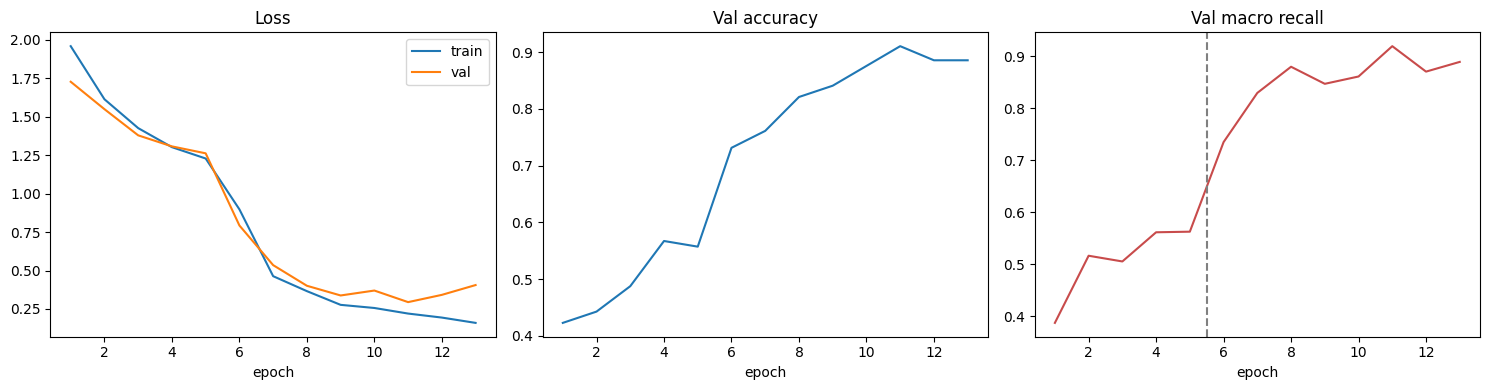

In [15]:
ep_range = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(ep_range, history["train_loss"], label="train")
plt.plot(ep_range, history["val_loss"], label="val")
plt.title("Loss"); plt.xlabel("epoch"); plt.legend()
plt.subplot(1, 3, 2)
plt.plot(ep_range, history["val_acc"]); plt.title("Val accuracy"); plt.xlabel("epoch")
plt.subplot(1, 3, 3)
plt.plot(ep_range, history["val_macro_recall"], color="#C84B4B")
plt.axvline(EPOCHS_HEAD + 0.5, ls="--", c="gray")
plt.title("Val macro recall"); plt.xlabel("epoch")
plt.tight_layout(); plt.show()

## 10 · Test evaluation — per-class report + 8x8 confusion matrix

                     precision    recall  f1-score   support

           adenosis      0.846     1.000     0.917        11
   ductal_carcinoma      0.976     0.900     0.936        90
       fibroadenoma      0.794     1.000     0.885        27
  lobular_carcinoma      0.737     0.875     0.800        16
 mucinous_carcinoma      0.947     0.900     0.923        20
papillary_carcinoma      0.923     0.923     0.923        13
    phyllodes_tumor      0.875     0.636     0.737        11
    tubular_adenoma      0.923     0.857     0.889        14

           accuracy                          0.901       202
          macro avg      0.878     0.886     0.876       202
       weighted avg      0.910     0.901     0.901       202



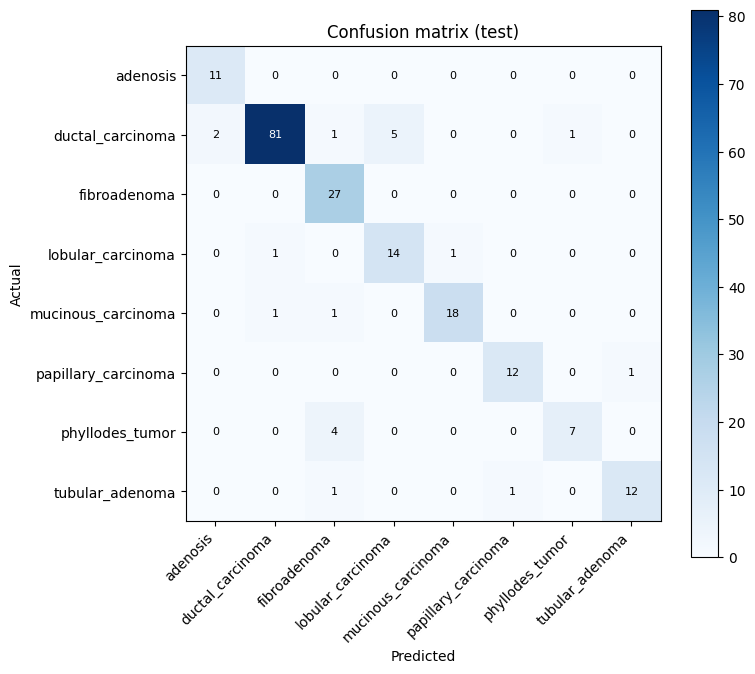

Macro recall (test): 0.886


In [16]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    yt, yp = [], []
    for x, y in loader:
        pred = model(x.to(DEVICE)).argmax(1).cpu()
        yt += y.tolist(); yp += pred.tolist()
    return np.array(yt), np.array(yp)

yt, yp = predict(model, test_loader)
print(classification_report(yt, yp, target_names=classes, digits=3, zero_division=0))

cm = confusion_matrix(yt, yp)
plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(NUM_CLASSES), classes, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), classes)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion matrix (test)")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
plt.colorbar(); plt.tight_layout(); plt.show()
print("Macro recall (test):",
      round(recall_score(yt, yp, average='macro', zero_division=0), 3))

## 11 · Predicted vs Actual gallery

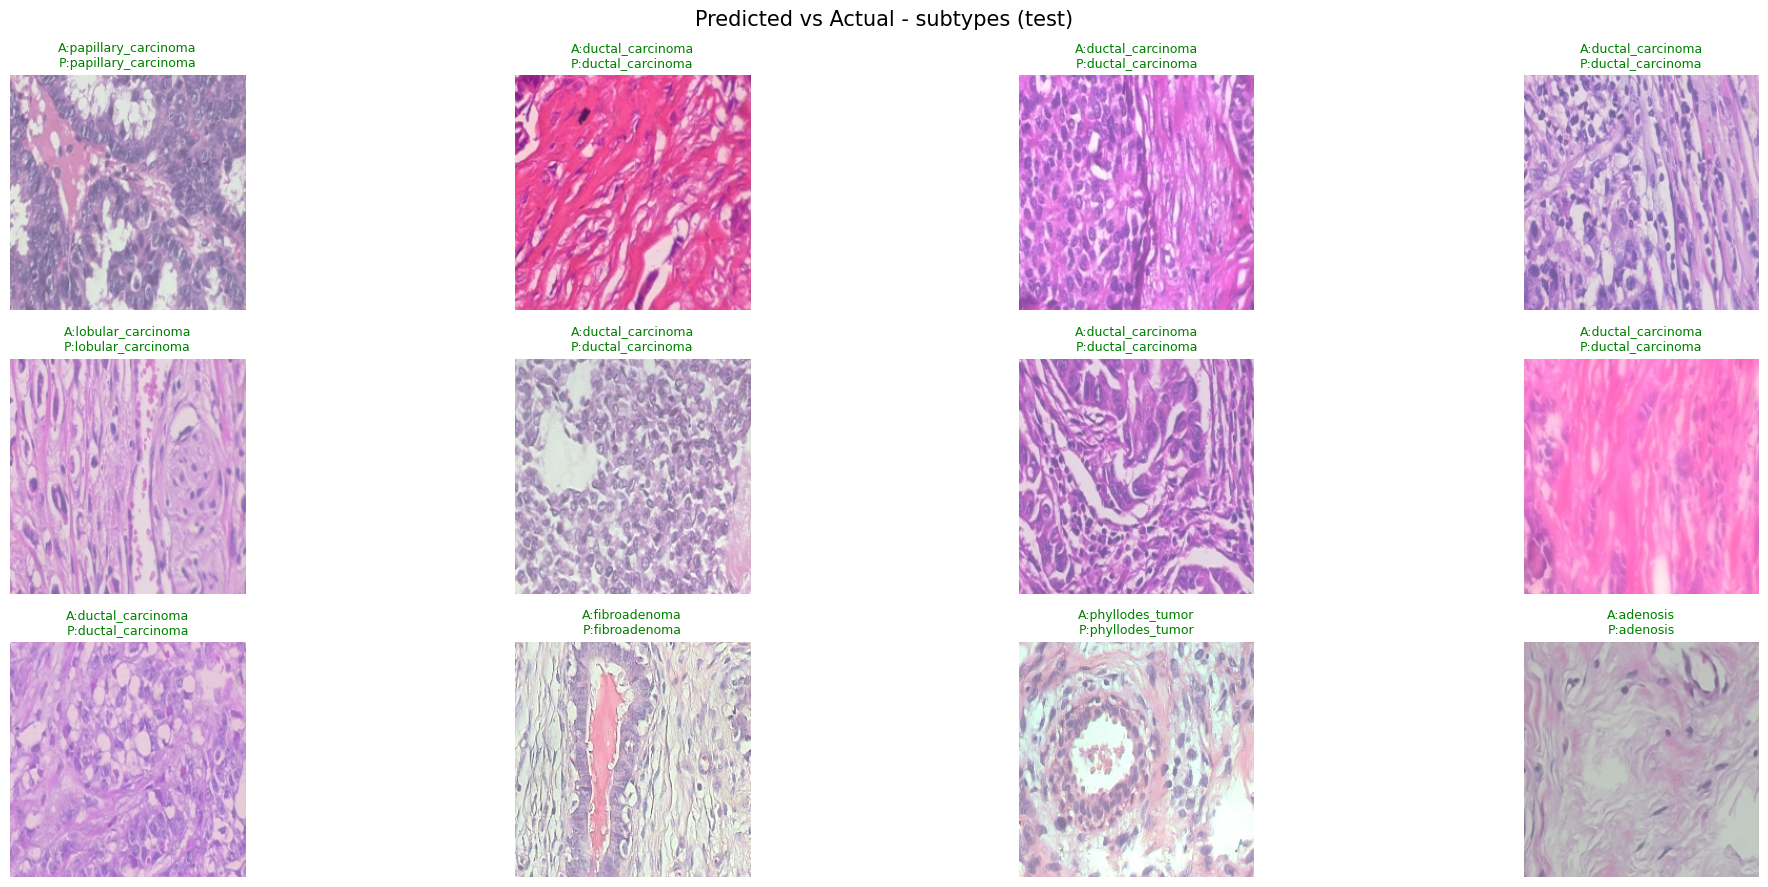

In [13]:
sample = random.sample(list(test_idx), 12)
plt.figure(figsize=(22, 9))
plt.suptitle("Predicted vs Actual - subtypes (test)", fontsize=15)
for n, i in enumerate(sample):
    img, y = eval_base[i]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(DEVICE)).argmax(1).item()
    plt.subplot(3, 4, n + 1); plt.imshow(denorm(img)); plt.axis("off")
    plt.title(f"A:{classes[y]}\nP:{classes[pred]}",
              color="green" if pred == y else "red", fontsize=9)
plt.tight_layout(); plt.show()

## 12 · Save the multiclass model

Separate artifact — your binary model stays untouched.

In [15]:
OUT = Path("model"); OUT.mkdir(exist_ok=True)
torch.save(model.state_dict(), OUT / "resnet18_multiclass_200x.pt")
meta = {
    "arch": "resnet18", 
    "task": "multiclass_8",
    "classes": classes, 
    "img_size": IMG_SIZE, 
    "mean": MEAN, 
    "std": STD,
}
(OUT / "metadata_multiclass_200x.json").write_text(json.dumps(meta, indent=2))

369